In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [3]:
df=pd.read_csv("Ice_cream selling data.csv")
df.columns

Index(['Temperature (°C)', 'Ice Cream Sales (units)'], dtype='object')

<Axes: xlabel='Ice Cream Sales (units)', ylabel='Count'>

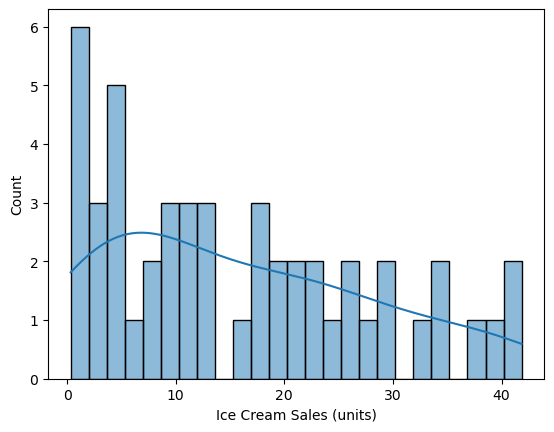

In [4]:
sns.histplot(data=df,x='Ice Cream Sales (units)',kde=True,bins=25)

<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

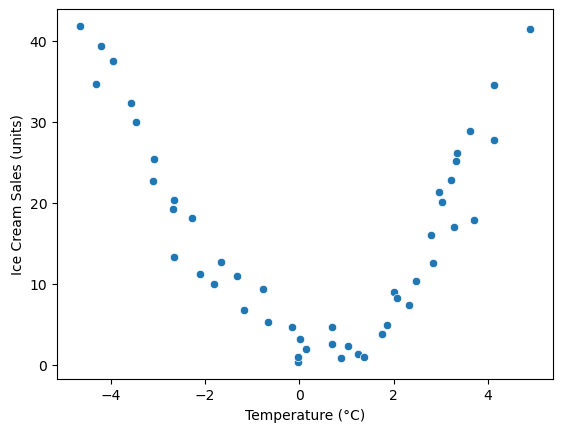

In [5]:
sns.scatterplot(data=df,y='Ice Cream Sales (units)',x='Temperature (°C)')

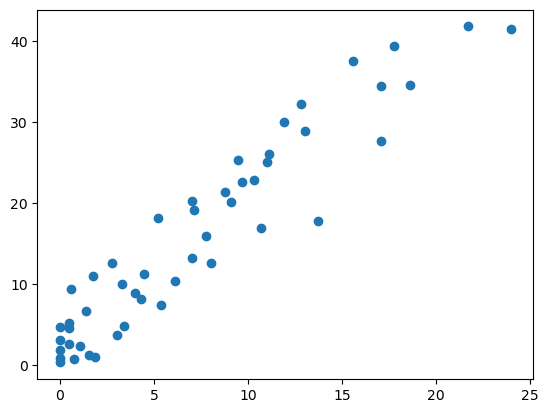

In [6]:
plt.scatter(x=df['Temperature (°C)']*df['Temperature (°C)'],y=df['Ice Cream Sales (units)'])

In [17]:
df=pd.read_csv('Ice_cream selling data.csv')
x=df[['Temperature (°C)']]
y=df['Ice Cream Sales (units)']

In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train)
print(x_train_poly)
x_test_poly=poly.transform(x_test)
print(x_test_poly)

[[ 1.00000000e+00 -2.11186969e+00  4.45999359e+00]
 [ 1.00000000e+00 -3.57855372e+00  1.28060467e+01]
 [ 1.00000000e+00  2.31859124e+00  5.37586534e+00]
 [ 1.00000000e+00 -2.67246083e+00  7.14204687e+00]
 [ 1.00000000e+00 -3.94966109e+00  1.55998227e+01]
 [ 1.00000000e+00 -3.10844012e+00  9.66239999e+00]
 [ 1.00000000e+00  3.21136614e+00  1.03128725e+01]
 [ 1.00000000e+00  3.27004407e+00  1.06931882e+01]
 [ 1.00000000e+00  4.13086796e+00  1.70640701e+01]
 [ 1.00000000e+00 -1.32637898e+00  1.75928121e+00]
 [ 1.00000000e+00 -2.65228679e+00  7.03462523e+00]
 [ 1.00000000e+00 -1.17312327e+00  1.37621820e+00]
 [ 1.00000000e+00  6.88780908e-01  4.74419139e-01]
 [ 1.00000000e+00  2.07510060e+00  4.30604249e+00]
 [ 1.00000000e+00  1.74000001e+00  3.02760004e+00]
 [ 1.00000000e+00 -4.66226268e+00  2.17366933e+01]
 [ 1.00000000e+00  3.33593241e+00  1.11284451e+01]
 [ 1.00000000e+00  1.99931037e+00  3.99724195e+00]
 [ 1.00000000e+00 -3.45571170e+00  1.19419433e+01]
 [ 1.00000000e+00  1.35981267e+

In [20]:
model=LinearRegression()
model.fit(x_train_poly,y_train)
y_pred=model.predict(x_test_poly)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))
print(model.coef_)
print(model.intercept_)

3.2299819836597266
14.878796440981466
0.8430551371938843
[ 0.         -0.70641926  1.87145125]
2.7683058295738636


In [27]:
df=pd.read_csv("Fish.csv")
df.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='object')

0.9672675055786748
0.9609431981523922
-422.82939763586364
-428.9175487768359
-1306.7895109267881
-3862.1572730379844
-7218.970277291126


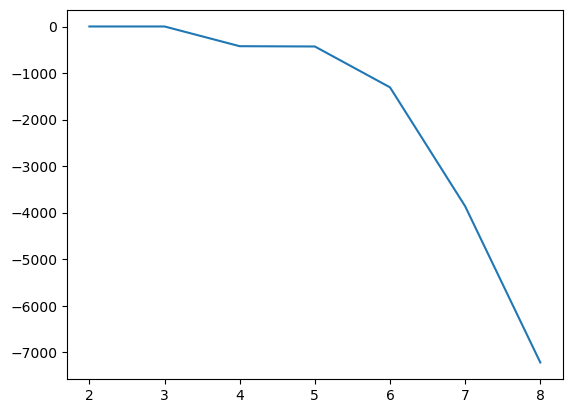

In [29]:
x=df.drop(['Species','Weight'],axis=1)
y=df['Weight']
r2=[]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
for i in range(2,9):
    poly=PolynomialFeatures(degree=i)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    model=LinearRegression()
    model.fit(x_train_poly,y_train)
    y_pred=model.predict(x_test_poly)
    r2.append(r2_score(y_test,y_pred))
    print(r2_score(y_test,y_pred))
plt.plot(range(2,9),r2)